In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.io import loadmat
from PIL import Image
import os
import glob

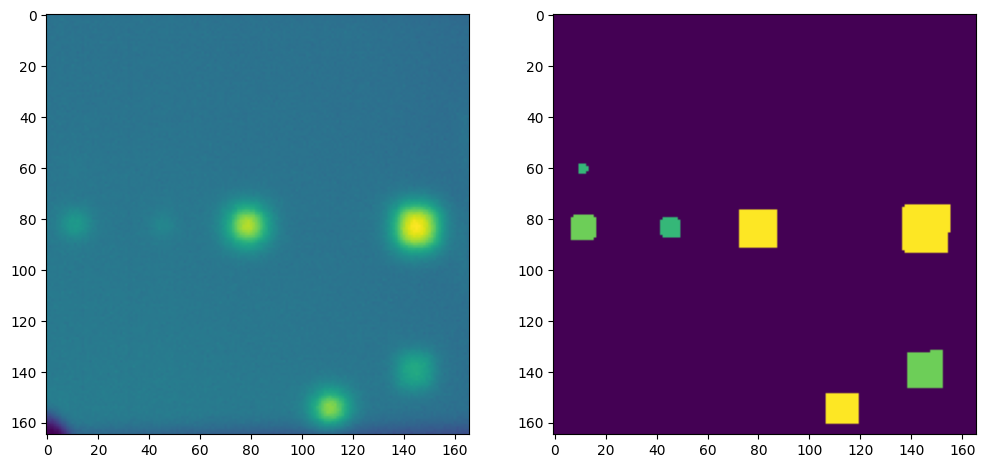

In [311]:
data=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Open_Source_Dataset/open_source_data_npz_rb/R_009.npz",allow_pickle=True)
sample=data['data']
mask=data['mask']

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(sample[200])

plt.subplot(1,2,2)
plt.imshow(mask)

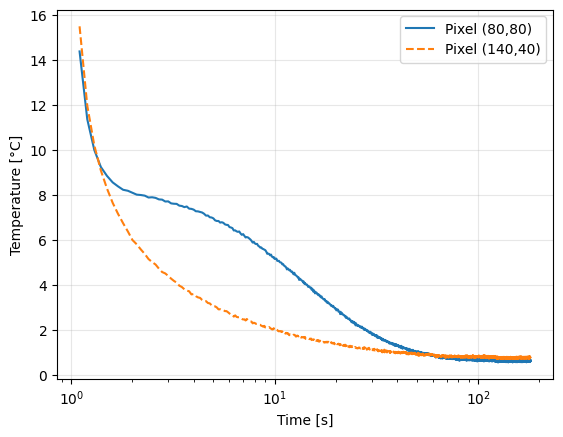

In [327]:
T,_,_=sample.shape
t=np.arange(T) * 0.1
plt.semilogx(t[11:],sample[11:,80,80],label='Pixel (80,80)')
plt.semilogx(t[11:],sample[11:,140,40],label='Pixel (140,40)',linestyle='--')
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Temperature [°C]')
plt.grid(alpha=0.3)
plt.show()

In [2]:
from helper_functions.helper_functions import Interpolate
resize = Interpolate(size=512)

Text(0.5, 1.0, 'Cropped mask')

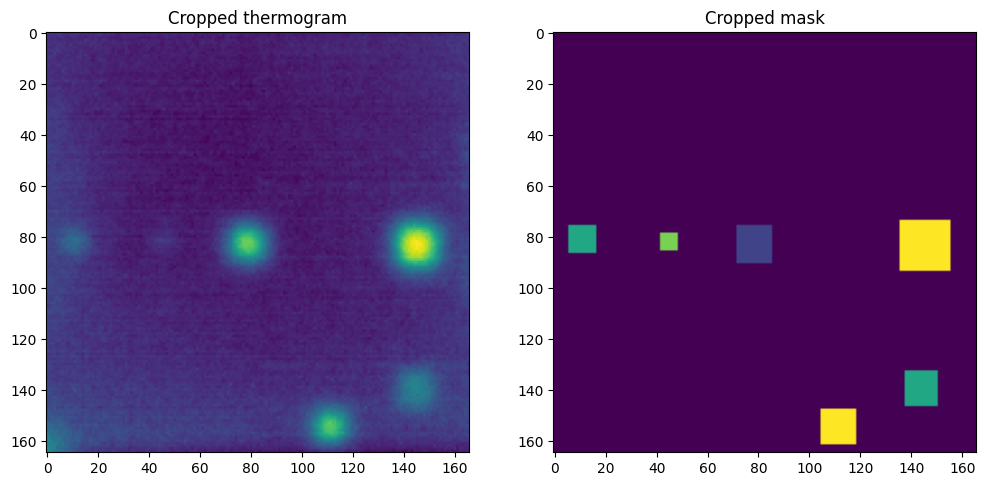

In [270]:
r_start=85
r_end=-70

c_start=45
c_end=-45

time_frame=200
data=loadmat("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Open_Source_Dataset/archive/data/R_009.mat")
mask=Image.open("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Open_Source_Dataset/archive/labels/manual_mask/R_009.png")
mask=np.array(mask)
mask=mask.T
bscan=data['imageArray']
bscan=np.moveaxis(bscan,-1,0)
bscan=np.transpose(bscan,(0,2,1))
plt.figure(figsize=(12,7))
plt.subplot(1,2,1)
plt.imshow(bscan[time_frame,r_start:r_end,c_start:c_end])
plt.title("Cropped thermogram")
plt.subplot(1,2,2)
plt.imshow(mask[r_start:r_end,c_start:c_end])
plt.title("Cropped mask")

In [266]:
data_crop=bscan[:,r_start:r_end,c_start:c_end]

In [267]:
import numpy as np


def replace_negative_outliers_outside_peak_3d(
    data,
    threshold_sigma=6.0,
    percentile=5,
    peak_buffer_left=10,
    peak_buffer_right=30,
    verbose=True,
):
    """
    Detect and replace negative corrupted frames in a 3D thermal sequence.

    The input tensor must have time on the first axis:

        data.shape = [T, H, W]

    The method is designed for corrupted frames that appear as sudden negative
    drops. It avoids modifying the real heating peak by excluding a protected
    frame window around the global maximum of the mean temperature curve.

    Detection logic
    ---------------
    For every internal frame t, an expected frame is estimated from its direct
    temporal neighbours:

        expected[t] = 0.5 * (data[t - 1] + data[t + 1])

    Then the residual is computed:

        residual[t] = data[t] - expected[t]

    Negative corrupted frames produce strongly negative residuals. Therefore,
    the detection score is based only on the negative side of the residual:

        score[t] = -percentile(residual[t], percentile)

    A high score means that at least part of the frame is much colder than
    expected from neighbouring frames.

    Replacement logic
    -----------------
    Every detected corrupted frame is replaced by the mean of the nearest
    available non-corrupted frame before it and the nearest available
    non-corrupted frame after it:

        corrected[t] = 0.5 * (corrected[left] + corrected[right])

    This avoids copying only the left or right frame.

    Parameters
    ----------
    data : np.ndarray
        Input thermal tensor with shape [T, H, W].

    threshold_sigma : float
        Robust z-score threshold for outlier detection.
        Higher value means less sensitive detection.

    percentile : float
        Percentile of residual values used to detect localized negative drops.
        Lower value makes the method more sensitive to small corrupted regions.

    peak_buffer_left : int
        Number of frames before the detected heating peak excluded from
        correction.

    peak_buffer_right : int
        Number of frames after the detected heating peak excluded from
        correction.

    verbose : bool
        If True, prints detected peak and corrupted frame indices.

    Returns
    -------
    corrected : np.ndarray
        Corrected tensor with shape [T, H, W].

    bad_frames : list[int]
        List of detected and replaced frame indices.

    scores : np.ndarray
        Negative anomaly score for every frame. Boundary frames are NaN.

    robust_z : np.ndarray
        Robust z-score for every frame. Protected and boundary frames are NaN.

    peak_frame : int
        Detected heating peak frame index.
    """

    data = np.asarray(data)

    if data.ndim != 3:
        raise ValueError(f"Expected 3D tensor [T, H, W], got shape {data.shape}")

    T, H, W = data.shape

    if T < 3:
        raise ValueError("At least 3 frames are required.")

    corrected = data.copy().astype(np.float32)

    # ------------------------------------------------------------------
    # Detect the global heating peak.
    #
    # The mean curve compresses every frame into one scalar value.
    # The peak frame is the frame with the largest mean temperature.
    # This region usually contains real high temporal curvature and should
    # not be modified by the outlier correction.
    # ------------------------------------------------------------------
    mean_curve = data.mean(axis=(1, 2))
    peak_frame = int(np.argmax(mean_curve))

    protected_start = max(1, peak_frame - peak_buffer_left)
    protected_end = min(T - 2, peak_frame + peak_buffer_right)

    protected_mask = np.zeros(T, dtype=bool)
    protected_mask[protected_start:protected_end + 1] = True

    # ------------------------------------------------------------------
    # Compute negative anomaly scores.
    #
    # Boundary frames are skipped because frame 0 has no previous frame and
    # frame T-1 has no next frame.
    # ------------------------------------------------------------------
    scores = np.full(T, np.nan, dtype=np.float32)

    for t in range(1, T - 1):
        expected = 0.5 * (data[t - 1] + data[t + 1])
        residual = data[t] - expected

        # Only negative deviations are important.
        # Example:
        #   residual percentile = -2.0  -> score = 2.0
        #   residual percentile =  0.1  -> score = -0.1
        neg_score = -np.percentile(residual, percentile)

        scores[t] = neg_score

    # ------------------------------------------------------------------
    # Estimate robust statistics only outside the protected peak region.
    #
    # Median and MAD are used instead of mean and standard deviation because
    # they are less sensitive to occasional corrupted frames.
    # ------------------------------------------------------------------
    valid_detection_frames = np.array(
        [t for t in range(1, T - 1) if not protected_mask[t]],
        dtype=int,
    )

    if len(valid_detection_frames) == 0:
        raise ValueError("No frames available for detection outside peak buffer.")

    valid_scores = scores[valid_detection_frames]

    median_score = np.nanmedian(valid_scores)
    mad_score = np.nanmedian(np.abs(valid_scores - median_score)) + 1e-12

    robust_z = np.full(T, np.nan, dtype=np.float32)
    robust_z[valid_detection_frames] = (
        0.6745 * (valid_scores - median_score) / mad_score
    )

    # ------------------------------------------------------------------
    # Select corrupted frames.
    #
    # Only frames outside the protected region can be selected.
    # ------------------------------------------------------------------
    bad_frames = valid_detection_frames[
        robust_z[valid_detection_frames] > threshold_sigma
    ].tolist()

    bad_set = set(bad_frames)

    # ------------------------------------------------------------------
    # Replace corrupted frames.
    #
    # For every corrupted frame t:
    #   1. Search left for nearest frame that is not corrupted.
    #   2. Search right for nearest frame that is not corrupted.
    #   3. Replace frame t with the mean of these two valid frames.
    #
    # If only one valid neighbour exists, the frame is copied from that side.
    # This fallback is needed only near boundaries or in unusual long corrupted
    # blocks.
    # ------------------------------------------------------------------
    for t in bad_frames:
        left = t - 1
        right = t + 1

        while left in bad_set and left > 0:
            left -= 1

        while right in bad_set and right < T - 1:
            right += 1

        left_is_valid = left >= 0 and left not in bad_set
        right_is_valid = right < T and right not in bad_set

        if left_is_valid and right_is_valid:
            corrected[t] = 0.5 * (corrected[left] + corrected[right])
        elif left_is_valid:
            corrected[t] = corrected[left]
        elif right_is_valid:
            corrected[t] = corrected[right]

    if verbose:
        print(f"Detected heating peak frame: {peak_frame}")
        print(f"Protected frame range: {protected_start} to {protected_end}")
        print(f"Detected corrupted frames: {bad_frames}")
        print(f"Number of replaced frames: {len(bad_frames)}")

        for t in bad_frames:
            print(
                f"Frame {t}: "
                f"score={scores[t]:.6f}, "
                f"robust_z={robust_z[t]:.2f}"
            )

    return corrected, bad_frames, scores, robust_z, peak_frame

data_corr, bad_frames, scores, robust_z, peak_frame = replace_negative_outliers_outside_peak_3d(
    data_crop,
    threshold_sigma=15.0,
    percentile=5,
    peak_buffer_left=15,
    peak_buffer_right=30,
    verbose=True,
)

Detected heating peak frame: 11
Protected frame range: 1 to 41
Detected corrupted frames: []
Number of replaced frames: 0


Text(0, 0.5, 'Camera output [a.u.]')

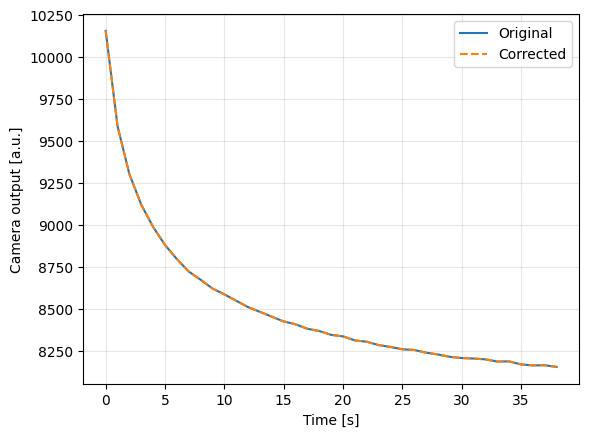

In [269]:
T,_,_=data_corr.shape
t=np.arange(T) * 0.1
plt.plot(data_crop[11:50,85,90],label="Original")
plt.plot(data_corr[11:50,85,90],label="Corrected",linestyle="--")
plt.legend()
plt.grid(alpha=0.3)
plt.xlabel("Time [s]")
plt.ylabel("Camera output [a.u.]")

In [ ]:


# Mapping from mask pixel values to distance from measured surface
PIXEL_TO_DEPTH_MM = {
    0: "sound / no defect",
    51: 0.5,
    102: 1.0,
    153: 1.5,
    204: 2.0,
    255: 2.5,
}


def inspect_png_masks(mask_folder):
    """
    Go through all PNG masks in folder and print unique pixel values
    together with corresponding defect burial depths.

    Parameters
    ----------
    mask_folder : str
        Path to folder containing grayscale PNG masks.
    """

    mask_paths = sorted(glob.glob(os.path.join(mask_folder, "*.png")))

    if len(mask_paths) == 0:
        print(f"No PNG masks found in: {mask_folder}")
        return

    for path in mask_paths:
        img = Image.open(path).convert("L")  # force grayscale
        mask = np.array(img)

        unique_values = np.unique(mask)

        print("=" * 80)
        print(f"Mask: {os.path.basename(path)}")
        print(f"Unique pixel values: {unique_values.tolist()}")

        print("Depths present:")
        for value in unique_values:
            value = int(value)

            if value in PIXEL_TO_DEPTH_MM:
                depth = PIXEL_TO_DEPTH_MM[value]

                if value == 0:
                    print(f"  pixel {value:3d} -> {depth}")
                else:
                    print(f"  pixel {value:3d} -> {depth:.1f} mm")
            else:
                print(f"  pixel {value:3d} -> UNKNOWN VALUE")

        print()


# Example usage
mask_folder = r"/home/kjaworski/Pulpit/Temporal_thermal_imaging/Open_Source_Dataset/archive/labels/automated_mask"
inspect_png_masks(mask_folder)

Mask: R_002.png
Unique pixel values: [0, 102, 153, 204]
Depths present:
  pixel   0 -> sound / no defect
  pixel 102 -> 1.0 mm
  pixel 153 -> 1.5 mm
  pixel 204 -> 2.0 mm

Mask: R_003.png
Unique pixel values: [0, 51, 102, 153, 204]
Depths present:
  pixel   0 -> sound / no defect
  pixel  51 -> 0.5 mm
  pixel 102 -> 1.0 mm
  pixel 153 -> 1.5 mm
  pixel 204 -> 2.0 mm

Mask: R_004.png
Unique pixel values: [0, 51, 102, 153, 204, 255]
Depths present:
  pixel   0 -> sound / no defect
  pixel  51 -> 0.5 mm
  pixel 102 -> 1.0 mm
  pixel 153 -> 1.5 mm
  pixel 204 -> 2.0 mm
  pixel 255 -> 2.5 mm

Mask: R_005.png
Unique pixel values: [0, 51, 102, 255]
Depths present:
  pixel   0 -> sound / no defect
  pixel  51 -> 0.5 mm
  pixel 102 -> 1.0 mm
  pixel 255 -> 2.5 mm

Mask: R_006.png
Unique pixel values: [0, 51, 102, 153, 204, 255]
Depths present:
  pixel   0 -> sound / no defect
  pixel  51 -> 0.5 mm
  pixel 102 -> 1.0 mm
  pixel 153 -> 1.5 mm
  pixel 204 -> 2.0 mm
  pixel 255 -> 2.5 mm

Mask: R_0

In [28]:
import os
import glob
import numpy as np
from PIL import Image
from collections import defaultdict

PIXEL_TO_DEPTH_MM = {
    0: 0.0,
    51: 0.5,
    102: 1.0,
    153: 1.5,
    204: 2.0,
    255: 2.5,
}

DEPTH_TO_PIXEL = {
    0.5: 51,
    1.0: 102,
    1.5: 153,
    2.0: 204,
    2.5: 255,
}


def analyze_column_bscan_split_strict_val(
    mask_folder,
    val_depth_mm,
    test_depth_mm,
    direction="columns",
):
    """
    Analyze B-scan split where:

    Train:
        columns containing only train depths and/or background.

    Validation:
        columns containing validation depth only, possibly with background,
        but no train depths and no test depth.

    Test:
        columns containing test depth.
        Test columns may be mixed with other depths because final metrics
        can be depth-aware.

    Background:
        columns containing only pixel value 0.
    """

    if val_depth_mm == test_depth_mm:
        raise ValueError("Validation and test depth must be different.")

    val_pixel = DEPTH_TO_PIXEL[val_depth_mm]
    test_pixel = DEPTH_TO_PIXEL[test_depth_mm]

    all_defect_pixels = set(DEPTH_TO_PIXEL.values())
    forbidden_for_train = {val_pixel, test_pixel}
    train_pixels = all_defect_pixels - forbidden_for_train

    mask_paths = sorted(glob.glob(os.path.join(mask_folder, "*.png")))

    if len(mask_paths) == 0:
        raise FileNotFoundError(f"No PNG masks found in: {mask_folder}")

    global_counts = defaultdict(int)
    per_file_results = []

    for path in mask_paths:
        mask = np.array(Image.open(path).convert("L"))

        if direction == "columns":
            n_bscans = mask.shape[1]
            slices = [mask[:, i] for i in range(mask.shape[1])]
        elif direction == "rows":
            n_bscans = mask.shape[0]
            slices = [mask[i, :] for i in range(mask.shape[0])]
        else:
            raise ValueError("direction must be 'columns' or 'rows'.")

        file_counts = defaultdict(int)

        for idx, bscan_mask in enumerate(slices):
            unique_values = set(np.unique(bscan_mask).astype(int).tolist())
            defect_values = unique_values - {0}

            is_background = len(defect_values) == 0

            has_val = val_pixel in defect_values
            has_test = test_pixel in defect_values
            has_train_depth = len(defect_values & train_pixels) > 0

            contains_only_train_depths = (
                len(defect_values) > 0
                and defect_values.issubset(train_pixels)
            )

            contains_only_val_depth = (
                defect_values == {val_pixel}
            )

            # Split assignment
            if is_background:
                split = "background_train_candidate"

            elif contains_only_train_depths:
                split = "train"

            elif contains_only_val_depth:
                split = "val_strict"

            elif has_test:
                split = "test_mixed_allowed"

            elif has_val and has_train_depth:
                split = "discarded_val_train_mixed"

            elif has_val and has_test:
                split = "discarded_val_test_mixed"

            else:
                split = "discarded_other"

            file_counts[split] += 1
            global_counts[split] += 1

        per_file_results.append(
            {
                "file": os.path.basename(path),
                "n_bscans": n_bscans,
                "train": file_counts["train"],
                "val_strict": file_counts["val_strict"],
                "test_mixed_allowed": file_counts["test_mixed_allowed"],
                "background": file_counts["background_train_candidate"],
                "discarded_val_train_mixed": file_counts["discarded_val_train_mixed"],
                "discarded_val_test_mixed": file_counts["discarded_val_test_mixed"],
                "discarded_other": file_counts["discarded_other"],
            }
        )

    print("=" * 100)
    print(f"STRICT VALIDATION split analysis for B-scans extracted by: {direction}")
    print(f"Validation depth: {val_depth_mm} mm -> pixel {val_pixel}")
    print(f"Test depth:       {test_depth_mm} mm -> pixel {test_pixel}")
    print(f"Train depths:     {[PIXEL_TO_DEPTH_MM[p] for p in sorted(train_pixels)]} mm")
    print("=" * 100)

    print("\nGLOBAL COUNTS")
    print(f"Train defect B-scans:          {global_counts['train']}")
    print(f"Strict validation B-scans:     {global_counts['val_strict']}")
    print(f"Test B-scans, mixed allowed:   {global_counts['test_mixed_allowed']}")
    print(f"Background train candidates:   {global_counts['background_train_candidate']}")
    print()
    print(f"Discarded val+train mixed:     {global_counts['discarded_val_train_mixed']}")
    print(f"Discarded val+test mixed:      {global_counts['discarded_val_test_mixed']}")
    print(f"Discarded other:               {global_counts['discarded_other']}")

    train_total_with_balanced_bg = (
        global_counts["train"] +
        min(global_counts["train"], global_counts["background_train_candidate"])
    )

    print(f"\nBalanced train size estimate:")
    print(
        f"{global_counts['train']} defect + "
        f"{min(global_counts['train'], global_counts['background_train_candidate'])} background "
        f"= {train_total_with_balanced_bg}"
    )

    print("\nPER FILE COUNTS")
    for r in per_file_results:
        print(
            f"{r['file']:12s} | "
            f"all={r['n_bscans']:4d} | "
            f"train={r['train']:4d} | "
            f"val={r['val_strict']:4d} | "
            f"test={r['test_mixed_allowed']:4d} | "
            f"bg={r['background']:4d} | "
            f"discard_vt={r['discarded_val_train_mixed']:4d}"
        )

    return per_file_results, dict(global_counts)

In [29]:
mask_folder = r"/home/kjaworski/Pulpit/Temporal_thermal_imaging/Open_Source_Dataset/archive/labels/automated_mask"

results, counts = analyze_column_bscan_split_strict_val(
    mask_folder=mask_folder,
    val_depth_mm=1.0,
    test_depth_mm=2.0,
    direction="columns",
)

STRICT VALIDATION split analysis for B-scans extracted by: columns
Validation depth: 1.0 mm -> pixel 102
Test depth:       2.0 mm -> pixel 204
Train depths:     [0.5, 1.5, 2.5] mm

GLOBAL COUNTS
Train defect B-scans:          1245
Strict validation B-scans:     489
Test B-scans, mixed allowed:   610
Background train candidates:   9567

Discarded val+train mixed:     249
Discarded val+test mixed:      0
Discarded other:               0

Balanced train size estimate:
1245 defect + 1245 background = 2490

PER FILE COUNTS
R_002.png    | all= 320 | train=  18 | val=  22 | test=  23 | bg= 257 | discard_vt=   0
R_003.png    | all= 320 | train=  21 | val=   6 | test=  25 | bg= 261 | discard_vt=   7
R_004.png    | all= 320 | train=  35 | val=  17 | test=  43 | bg= 207 | discard_vt=  18
R_005.png    | all= 320 | train=  13 | val=   4 | test=   0 | bg= 303 | discard_vt=   0
R_006.png    | all= 320 | train=  36 | val=  16 | test=  40 | bg= 214 | discard_vt=  14
R_007.png    | all= 320 | train=  27

In [30]:
depths = [0.5, 1.0, 1.5, 2.0, 2.5]

all_split_counts = []

for test_depth in depths:
    for val_depth in depths:
        if val_depth == test_depth:
            continue

        _, counts = analyze_column_bscan_split_strict_val(
            mask_folder=mask_folder,
            val_depth_mm=val_depth,
            test_depth_mm=test_depth,
            direction="columns",
        )

        train = counts.get("train", 0)
        bg = counts.get("background_train_candidate", 0)

        all_split_counts.append({
            "val_depth": val_depth,
            "test_depth": test_depth,
            "train": train,
            "val_strict": counts.get("val_strict", 0),
            "test_mixed_allowed": counts.get("test_mixed_allowed", 0),
            "background": bg,
            "balanced_train_total": train + min(train, bg),
            "discarded_val_train_mixed": counts.get("discarded_val_train_mixed", 0),
            "discarded_val_test_mixed": counts.get("discarded_val_test_mixed", 0),
        })


print("\nSUMMARY OF ALL 20 STRICT-VALIDATION SPLITS")
print("=" * 110)

for s in all_split_counts:
    print(
        f"val={s['val_depth']:.1f} mm | "
        f"test={s['test_depth']:.1f} mm | "
        f"train={s['train']:5d} | "
        f"val_strict={s['val_strict']:5d} | "
        f"test={s['test_mixed_allowed']:5d} | "
        f"bg={s['background']:5d} | "
        f"balanced_train={s['balanced_train_total']:5d} | "
        f"discard_val_train={s['discarded_val_train_mixed']:5d}"
    )

STRICT VALIDATION split analysis for B-scans extracted by: columns
Validation depth: 1.0 mm -> pixel 102
Test depth:       0.5 mm -> pixel 51
Train depths:     [1.5, 2.0, 2.5] mm

GLOBAL COUNTS
Train defect B-scans:          1032
Strict validation B-scans:     489
Test B-scans, mixed allowed:   775
Background train candidates:   9567

Discarded val+train mixed:     297
Discarded val+test mixed:      0
Discarded other:               0

Balanced train size estimate:
1032 defect + 1032 background = 2064

PER FILE COUNTS
R_002.png    | all= 320 | train=  23 | val=  22 | test=   0 | bg= 257 | discard_vt=  18
R_003.png    | all= 320 | train=  25 | val=   6 | test=  28 | bg= 261 | discard_vt=   0
R_004.png    | all= 320 | train=  51 | val=  17 | test=  23 | bg= 207 | discard_vt=  22
R_005.png    | all= 320 | train=  10 | val=   4 | test=   3 | bg= 303 | discard_vt=   0
R_006.png    | all= 320 | train=  12 | val=  16 | test=  59 | bg= 214 | discard_vt=  19
R_007.png    | all= 320 | train=  24 